# Fine-tuning a claim detector

Claim detection asks whether a sentence contains something a fact-checker could go and
verify. It is upstream of fact-checking: whether the claim is *true* is a separate problem.

`The unemployment rate fell to 3.5% last year` is a claim.  
`I think we should lower taxes` is not.


In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, '..')

import json
import pandas as pd

from finetuning import config as C, data as D, plots as P

pd.set_option('display.width', 140)


## Data

12,997 human-labelled sentences from three corpora, on a frozen 80/20 train/test split.
Train is split again into fit / validation / calibration (80/10/10), all stratified, so the
test set is touched exactly once at the end.

The out-of-domain set is 911 English tweets from CheckThat! 2022, used only for evaluation.


In [2]:
train_df, test_df = D.load_splits()
ood_df = D.load_ood()
sources = D.load_sources()
print(f'train {len(train_df)}   test {len(test_df)}   out-of-domain {len(ood_df)}')


train 10397   test 2600   out-of-domain 911


### Source composition

The three corpora have very different positive rates. AVeriTeC contributes ~3,000 rows that
are all labelled 1, because it was built from claims that had already been fact-checked.
That matters later: a model can score well by recognising which corpus a sentence came from
instead of learning what a claim is.


In [3]:
D.source_summary(sources)


,n,pct_positive
source,,
AVeriTeC,3068,100.00
Claimbuster,7976,25.00
PoliClaim,1953,59.09
Total,12997,47.83


### Example rows


In [4]:
pd.concat([train_df[train_df.label == 1].head(3),
           train_df[train_df.label == 0].head(3)])[['label', 'text']]


,label,text
2,1,He voted against student loans; he voted again...
4,1,"In the UK in 2020 there were 48,000 illegal im..."
7,1,In Kenya the County Governments’ allocation of...
0,0,I would like for them to look you in the eye a...
1,0,We absolutely have to make more progress and t...
3,0,I think that would be the greatest use of a de...


### Source provenance

The released split files are `text,label` only, so which corpus a row came from is not
recoverable from them. This joins each row back to its source by exact text match, which is
what makes the per-source breakdown in notebook 02 possible.

`unmatched` is one row whose text is null - a bug in the released data, dropped explicitly
during training rather than left to fail quietly.


In [5]:
D.join_report(D.attach_source(train_df, sources))


,n,pct
source,,
Claimbuster,6350,61.08
AVeriTeC,2476,23.81
PoliClaim,1570,15.10
unmatched,1,0.01


## Baseline

TF-IDF over words and bigrams, fed to logistic regression. No embeddings, no context, no
pretraining - just weighted word frequencies.

It runs in about 20 seconds and sets the floor. Any transformer number has to be read
against what a bag of words already gets on the same split.


In [6]:
!cd .. && .venv/bin/python -m finetuning.baseline



=== test (in-domain) ===
                       accuracy  precision  recall      f1       n  pred_positive_rate
tfidf+logreg             0.8488     0.8516  0.8186  0.8348  2600.0              0.4485
all-positive baseline    0.4665     0.4665  1.0000  0.6362  2600.0              1.0000

=== ood (tweets) ===
                       accuracy  precision  recall      f1      n  pred_positive_rate
tfidf+logreg             0.6498     0.6498  0.9634  0.7761  911.0              0.9341
all-positive baseline    0.6301     0.6301  1.0000  0.7731  911.0              1.0000

=== by source (in-domain test) ===
             accuracy  precision  recall      f1       n  pred_positive_rate  true_positive_rate
AVeriTeC       0.9611     1.0000  0.9611  0.9802   591.0              0.9611              1.0000
Claimbuster    0.8376     0.6651  0.7012  0.6827  1626.0              0.2626              0.2491
PoliClaim      0.7232     0.8246  0.6498  0.7268   383.0              0.4465              0.5666
ALL      

## Training

BERT-base-uncased, full finetune, binary classification head. 3 epochs at `max_length=64`.
The corpus is short — median 21 tokens, 99th percentile 74 — so 64 truncates about 2.1%
of rows. 128 was the first choice and it sent an 8GB machine into swap for no measurable
gain.

Run from a terminal rather than from this notebook — a Jupyter kernel and a 110M-parameter
finetune competing for the same 8GB is what caused the swapping:

```
python -m finetuning.train --model bert --max-length 64 --epochs 3
```

It writes logits and mean-pooled embeddings for every split to `artifacts/results/*.npz`,
so notebook 02 never has to reload the model.


In [7]:
run = json.loads((C.MODELS / 'bert-seed42' / 'run.json').read_text())
pd.Series({k: v for k, v in run.items() if k != 'log_history'})


model                                                           bert
checkpoint                             google-bert/bert-base-uncased
seed                                                              42
device                                                           mps
hparams            {'max_length': 64, 'batch_size': 16, 'eval_bat...
minutes                                                        68.85
final_loss                                                  0.128432
n_fit                                                           8316
n_val                                                           1040
n_cal                                                           1040
steps_per_epoch                                                  520
dtype: object

### Loss

Training loss is measured on the data the model is fitting. Validation loss is measured on
held-out rows it never sees.

While both fall together the model is learning. When validation flattens or turns up while
training keeps dropping, it has started memorising - and that point is where the epoch
count should be set, rather than inherited from someone else's paper.


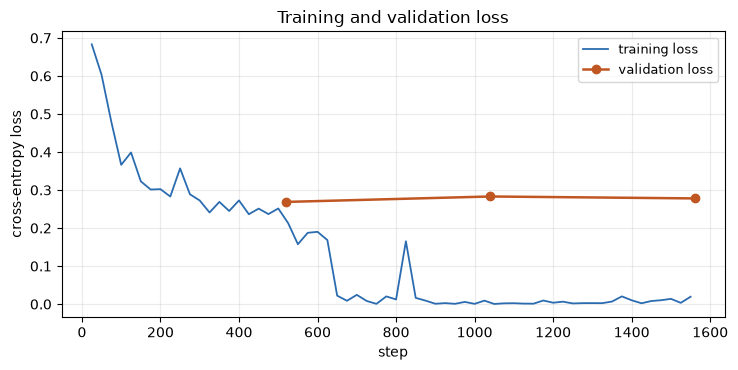

In [8]:
P.loss_curves(run['log_history']);


### Validation metrics by epoch


,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_n,eval_pred_positive_rate,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.268727,0.893269,0.912951,0.860,0.885685,1040,0.452885,9.3083,111.729,1.826,1.0,520
1,0.283022,0.897115,0.871456,0.922,0.896016,1040,0.508654,10.9058,95.363,1.559,2.0,1040
2,0.277965,0.897115,0.915433,0.866,0.890031,1040,0.454808,8.5762,121.266,1.982,3.0,1560


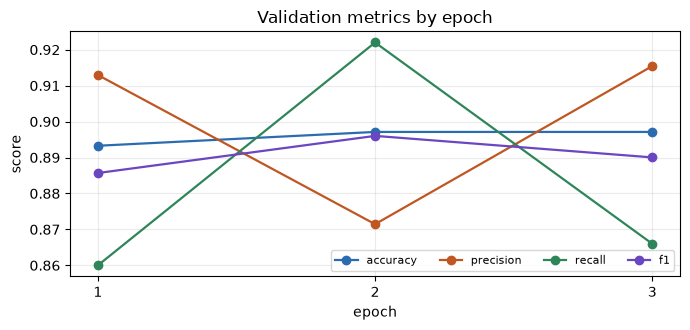

In [9]:
P.eval_metrics(run['log_history']);
pd.DataFrame([h for h in run['log_history'] if 'eval_loss' in h])

---

Artifacts are written. Continue in `02_analysis.ipynb`.
